In [1]:
import pandas as pd
import numpy as np

import sys
import os

sys.path.append(os.path.abspath("../src"))

from ebe import Population
import search_space
import data_preprocessing as dp

In [2]:
DATA_ID = 54
SEED = 13

In [3]:
# Load Data
X_train, y_train, X_val, y_val, X_test, y_test = dp.get_preprocessed_data(
        dataset_id=DATA_ID,
        scaling=True,
        random_seed=SEED,
        return_as='tensor',
        task_type='classification',
        categorical_strategy='label', 
        verbose=True
    )

input_size, output_size = dp.get_tensor_sizes(X_train, y_train)

Loading Dataset: vehicle


In [4]:

s_space = search_space.SearchSpace(input_size=input_size, 
                                       output_size=output_size)

In [5]:
import json
starting_path = '../experiments/ebe_vs/v2'
naml_path = os.path.join(starting_path,'naml')
with open(os.path.join(naml_path, f'{DATA_ID}_{SEED}_NAML.json')) as f:
    naml_results = json.load(f)
    naml_time_taken = naml_results["time_taken"]
    naml_max_test_acc = naml_results["test_accuracy_best_non_nn_model"]


with open(os.path.join(starting_path, f'standard/{DATA_ID}_{SEED}_ML.json')) as f:
    standard_results = json.load(f)
    ml_time_taken = standard_results["hist_gradient_boosting_training_time_sec"]
    ml_max_test_acc = standard_results["best_accuracy"]


max_metric = max(naml_max_test_acc, ml_max_test_acc)


In [6]:
naml_max_test_acc

0.8411764705882353

In [7]:
BUDGET_FACTOR = 10
N_INDIVIDUALS = 25
starting_instances = int(0.1 * len(X_train))

time_budget_ebe = max(ml_time_taken * BUDGET_FACTOR, 30)
# percentile_drop = 25
baseline_metric = max_metric
population = Population(s_space, 
                            size=N_INDIVIDUALS,
                            starting_instances=starting_instances,
                            seed=SEED)

ebe_results_final = population.run_ebe(
                            X_train, y_train, X_val, y_val,
                            baseline_metric=baseline_metric,
                            max_generations=150,
                            time_budget=time_budget_ebe,
                            inject_fraction=0.2,
                            base_drop=0.2,
                            max_drop=0.3,
                            track_all_models=False)
ebe_results_final.head(10)


=== Generation 1 ===
[Prune] Skipped pruning, not enough anchors yet.

=== Generation 2 ===
[Prune] total=25, hopeless=5, dropped=7, kept=18 

=== Generation 3 ===
[Prune] total=25, hopeless=14, dropped=14, kept=11 

=== Generation 4 ===
[Prune] total=25, hopeless=5, dropped=7, kept=18 

=== Generation 5 ===
[Prune] total=25, hopeless=12, dropped=13, kept=12 

=== Generation 6 ===
[Prune] total=25, hopeless=5, dropped=8, kept=17 

=== Generation 7 ===
[Prune] total=25, hopeless=6, dropped=8, kept=17 

=== Generation 8 ===
[Prune] total=25, hopeless=8, dropped=10, kept=15 

=== Generation 9 ===
[Prune] total=25, hopeless=6, dropped=9, kept=16 

=== Generation 10 ===
[Prune] total=25, hopeless=5, dropped=8, kept=17 

=== Generation 11 ===
[Prune] total=25, hopeless=7, dropped=10, kept=15 

=== Generation 12 ===
[Prune] total=25, hopeless=4, dropped=8, kept=17 

=== Generation 13 ===
[Prune] total=25, hopeless=4, dropped=8, kept=17 

=== Generation 14 ===
[Prune] total=25, hopeless=8, dr

,id,batch_size,n_instances,epochs_trained,batches_trained,efforts,cumulative_times,arch_hidden_layers,arch_shape,arch_depth,...,forecast_horizon_time,p_above_goal,last_train_acc,last_train_loss,last_val_acc,last_val_loss,total_batch_time,avg_batch_time,total_epoch_time,avg_epoch_time
12,575,8,"[54, 75]",1,7,"[0.0020003318786621094, 0.002000093460083008, ...","[0.0020003318786621094, 0.004000425338745117, ...","[43, 21, 17, 256, 128]",mutated,4,...,0.368973,0.385009,0.500000,0.619409,0.360294,1.618429,0.0,0.0,0.017997,0.008999
10,572,8,"[54, 75]",1,7,"[0.0014536380767822266, 0.0010006427764892578,...","[0.0014536380767822266, 0.0024542808532714844,...","[43, 21, 17, 256, 128]",mutated,4,...,0.370463,0.310342,0.500000,1.424590,0.529412,1.096980,0.0,0.0,0.018918,0.009459
9,570,8,"[54, 75]",1,7,"[0.0015027523040771484, 0.0020465850830078125,...","[0.0015027523040771484, 0.003549337387084961, ...","[43, 21, 17, 256, 64, 32, 64]",mutated,4,...,0.734628,0.207669,0.333333,0.882578,0.492647,1.108628,0.0,0.0,0.029189,0.014595
5,562,8,"[54, 75, 105]",2,17,"[0.002001047134399414, 0.0010004043579101562, ...","[0.002001047134399414, 0.0030014514923095703, ...","[43, 21, 17, 256, 128]",mutated,4,...,0.548468,0.091000,0.666667,1.065962,0.492647,1.369290,0.0,0.0,0.046010,0.011503
3,558,8,"[54, 75, 105]",2,17,"[0.0019996166229248047, 0.00099945068359375, 0...","[0.0019996166229248047, 0.0029990673065185547,...","[43, 21, 17, 256, 128]",mutated,4,...,0.377047,0.009333,0.000000,1.536583,0.492647,1.212230,0.0,0.0,0.046300,0.011575
4,559,8,"[54, 75, 105]",2,17,"[0.0019996166229248047, 0.0015022754669189453,...","[0.0019996166229248047, 0.00350189208984375, 0...","[43, 21, 17, 256, 64, 32]",mutated,4,...,0.549504,0.007000,0.000000,1.798216,0.352941,1.503627,0.0,0.0,0.047415,0.011854
0,549,8,"[54, 75, 105, 147]",3,31,"[0.0019998550415039062, 0.00099945068359375, 0...","[0.0019998550415039062, 0.0029993057250976562,...","[43, 21, 17, 256, 64, 32]",mutated,4,...,0.722633,0.004667,1.000000,0.431742,0.514706,1.110648,0.0,0.0,0.102005,0.017001
11,574,8,"[54, 75]",1,7,"[0.002000093460083008, 0.002000570297241211, 0...","[0.002000093460083008, 0.004000663757324219, 0...","[43, 21, 17, 256, 64, 32]",mutated,4,...,0.733165,0.002333,0.166667,1.768044,0.308824,1.235093,0.0,0.0,0.026263,0.013131
6,565,512,"[54, 75]",1,1,[0.0010013580322265625],[0.0010013580322265625],"[46, 33, 23]",pyramid,3,...,NaN,0.002333,0.277778,1.379944,0.404412,1.305918,0.0,0.0,0.002003,0.001001
2,553,512,"[54, 75, 105]",2,2,"[0.0040683746337890625, 0.003999471664428711]","[0.0040683746337890625, 0.008067846298217773]","[8, 57, 66, 43, 15, 16, 53, 15, 4, 51, 67, 76,...",irregular,16,...,NaN,0.002333,0.240000,1.409689,0.257353,1.394576,0.0,0.0,0.016136,0.004034


In [8]:
# Train by ES the best model
population.final_decision()

{'ShouldYouEvenNN?': True,
 'Exp. Utility': 0.05038706443279632,
 'p_above_goal': 0.3850090849825164,
 'benefit': 0.13229541863196081,
 'cost': 0.0008908646106719971}

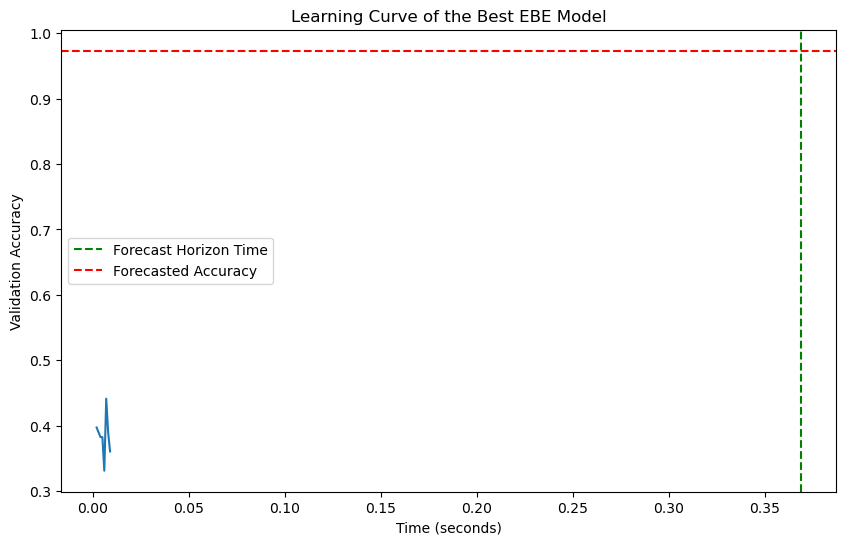

In [9]:
# plot the lc of the best model 
row = ebe_results_final.iloc[0]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.lineplot(x=row['cumulative_times'], y=row['val_acc'])
plt.title('Learning Curve of the Best EBE Model')
plt.xlabel('Time (seconds)')
plt.ylabel('Validation Accuracy')
plt.axvline(x=row["forecast_horizon_time"], color='g', linestyle='--', label='Forecast Horizon Time')

forecast = row['forecasted_val_acc']
plt.axhline(y=forecast, color='r', linestyle='--', label='Forecasted Accuracy')
plt.legend()

Forecast fidelity report:
  MAE : 0.1693721646195325
  Bias: -0.14457308930634022
    id  forecasted_val_acc  fidelity_val_acc     delta
4  558            0.688002          0.750000  0.061998
3  562            0.813198          0.750000 -0.063198
0  572            0.973716          0.750000 -0.223716
2  570            0.899477          0.661765 -0.237712
1  575            0.973472          0.713235 -0.260237


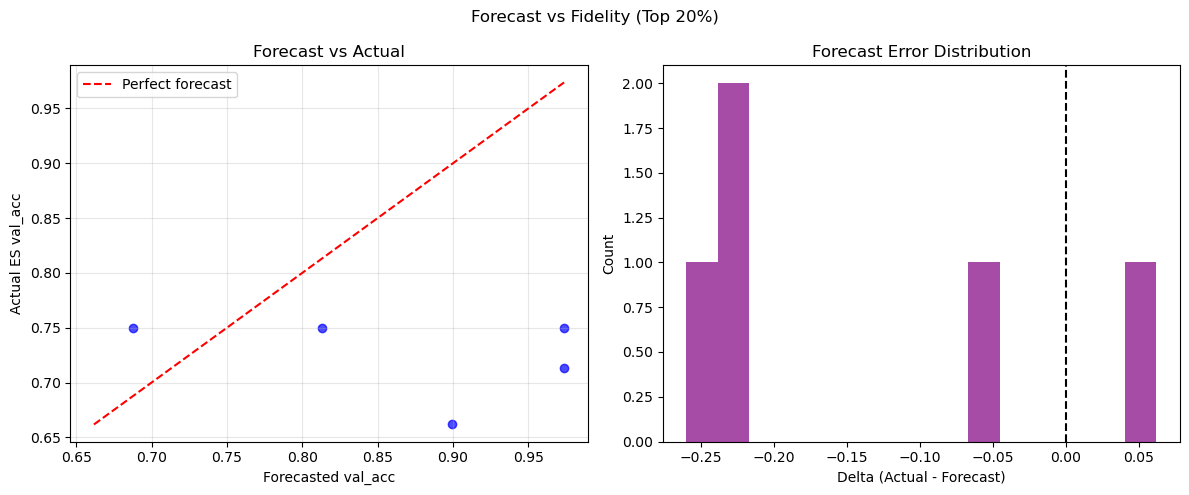

In [10]:
fidelity_ledger = population.fidelity_ledger
report = population.compare_forecast_vs_fidelity()

print("Forecast fidelity report:")
print("  MAE :", report["MAE"])
print("  Bias:", report["Bias"])
print(report["details"])

from utils_viz import plot_forecast_vs_fidelity
plot_forecast_vs_fidelity(report, title="Forecast vs Fidelity (Top 20%)")


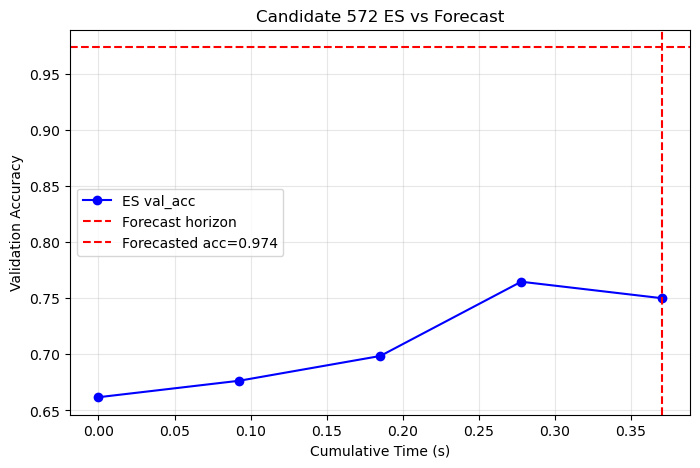

In [11]:
from utils_viz import plot_es_learning_curve_from_ledger
cand_id = fidelity_ledger.iloc[0]["id"]
row = fidelity_ledger[fidelity_ledger["id"] == cand_id].iloc[0]
plot_es_learning_curve_from_ledger(row)


In [12]:
row

id                                                                     572
forecasted_val_acc                                                0.973716
forecast_horizon_time                                             0.370463
fidelity_val_acc                                                      0.75
fidelity_train_acc                                                    0.75
fidelity_val_loss                                                 0.526693
learning_curve           {'es_train_losses': [0.650622546672821, 0.8813...
Name: 0, dtype: object

In [ ]:
{'es_train_losses': [0.650622546672821, 0.8813890218734741, 0.32123228907585144, 0.19689412415027618, 0.321052610874176], 'es_val_losses': [0.7334202650715324, 0.5652439348837909, 0.6654150652534822, 0.4993840342058855, 0.5266934545601115], 'es_train_accs': [0.75, 0.5, 0.75, 1.0, 0.75], 'es_val_accs': [0.6617647058823529, 0.6764705882352942, 0.6985294117647058, 0.7647058823529411, 0.75]}